**MÓDULO # 12 - ANÁLITICA DE REDES SOCIALES**

---



**Librerías** 

In [1]:
import networkx as nx
from matplotlib import pyplot as plt

**Recursos**

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **TEMA 1. Construcción de Redes**

### **Matriz de adyacencia**

Incluir todo el código ocupado en el NUTRE de este subtema. 

In [3]:
A = [[0, 1, 1, 1],
[1, 0, 1, 0],
[1, 1, 0, 0],
[1, 0, 0, 0]]

In [4]:
from itertools import chain # para recorrer la lista de arcos
G = nx.DiGraph()
edges = chain.from_iterable([(i, j)
for j, column in enumerate(row)
if A[i][j]] for i, row in enumerate(A))
G.add_edges_from(edges)
print(G.edges(data=True))

[(0, 1, {}), (0, 2, {}), (0, 3, {}), (1, 0, {}), (1, 2, {}), (2, 0, {}), (2, 1, {}), (3, 0, {})]


In [ ]:
from itertools import chain # For flattening the list of edges
G = nx.Graph()
edges = chain.from_iterable([(i, j, {"weight": A[i][j]})
for j, column in enumerate(row)
if A[i][j]] for i, row in enumerate(A))
G.add_edges_from(edges)
print(G.edges(data=True))

[(0, 1, {'weight': 1}), (0, 2, {'weight': 1}), (0, 3, {'weight': 1}), (1, 2, {'weight': 1})]


### **Modelado de datos**

**Edge list**

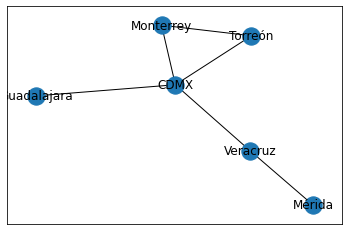

In [5]:
data_dir_distancia = '/content/drive/MyDrive/Colab Notebooks/PROFUNDIZA_PARTICIPANTE/data/distancias_ciudades.txt'
# Read edge list
G = nx.read_edgelist(data_dir_distancia)
# Draw network
pos = nx.spring_layout(G)
nx.draw_networkx(G, pos)

In [ ]:
print(G.edges(data=True))

[('Torreón', 'CDMX', {'distancia en km': 1031}), ('Torreón', 'Monterrey', {'distancia en km': 316}), ('CDMX', 'Guadalajara', {'distancia en km': 540}), ('CDMX', 'Veracruz', {'distancia en km': 420}), ('CDMX', 'Monterrey', {'distancia en km': 900}), ('Mérida', 'Veracruz', {'distancia en km': 1040})]


**Directed edge list**

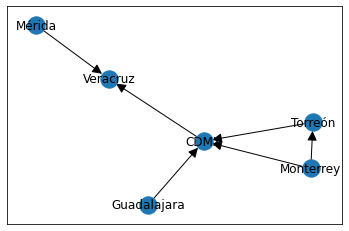

In [ ]:
data_dir_vuelos = '/content/drive/MyDrive/Colab Notebooks/PROFUNDIZA_PARTICIPANTE/fata/vuelos.txt'
# Read edge list
G = nx.read_edgelist(data_dir_vuelos,
    create_using=nx.DiGraph)
# Draw network
nx.draw_networkx(G, pos, arrowsize=20)

**Weighted edge list**

{('CDMX',
  'Guadalajara'): Text(0.0937793292291562, -0.39224980716888774, '0.9'),
 ('CDMX', 'Monterrey'): Text(-0.12240699880068315, -0.2183742716703212, '1.0'),
 ('CDMX', 'Veracruz'): Text(-0.060741156835901575, 0.2520883428508919, '3.0'),
 ('Mérida', 'Veracruz'): Text(-0.17828715182689886, 0.7518110303872114, '2.0'),
 ('Torreón', 'CDMX'): Text(0.2054358159064045, -0.1406323266206414, '1.0'),
 ('Torreón',
  'Monterrey'): Text(0.08450782259774269, -0.3595612232183236, '0.7')}

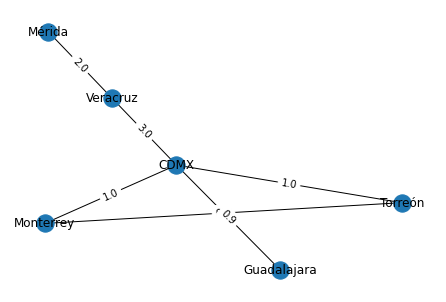

In [ ]:
data_dir_horas = '/content/drive/MyDrive/Colab Notebooks/PROFUNDIZA_PARTICIPANTE/data/horas_vuelo.txt'

# Read edge list
G = nx.read_weighted_edgelist(data_dir_horas)

pos=nx.spring_layout(G)
nx.draw(G, pos, with_labels=True)
edge_weight = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_weight)


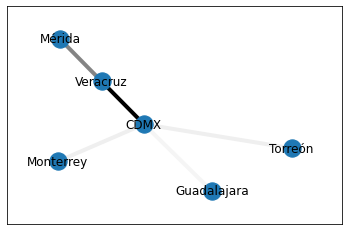

In [ ]:
data_dir_horas = '/content/drive/MyDrive/Colab Notebooks/PROFUNDIZA_PARTICIPANTE/data/horas_vuelo.txt'

# Read edge list
G = nx.read_weighted_edgelist(data_dir_horas)
# Extract weights
weights = [d['weight'] for s, t, d in G.edges(data=True)]
# Draw network
ax = plt.subplot(111)
nx.draw_networkx(G, pos, width=4, edge_color=weights, edge_cmap=plt.cm.Greys)
ax.margins(0.15, 0.15)

Edge list with edge attributes

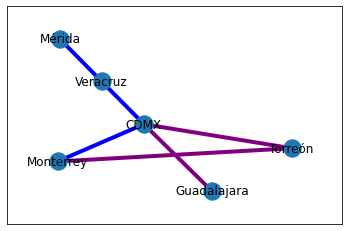

In [ ]:
data_dir_airline = '/content/drive/MyDrive/Colab Notebooks/PROFUNDIZA_PARTICIPANTE/data/vuelos_airline.txt'
# Read edge list
G = nx.read_edgelist(data_dir_airline,
                     data=[('weight', float),('color', str)])
# Extract colors
colors = [d['color'] for s, t, d in G.edges(data=True)]
# Draw network
ax = plt.subplot(111)
nx.draw_networkx(
    G, pos, width=4, edge_color=colors)
ax.margins(0.15, 0.15)

##**Solución Activate tema 1**



1. Cargar los datos a NetworkX

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/PROFUNDIZA_PARTICIPANTE/data/'
# Read edge list
rates = path + 'user_movie_rating.txt'

2. Una red que nos permite observar que película fue visto por tal usuario

{('A1TADCM7YWPQ8M',
  '0000000868'): Text(-0.4755124575225137, -0.14743337718650512, '2.0'),
 ('A2IIIDRK3PRRZY',
  '0000000116'): Text(0.49838856277369725, 0.9515605200813747, '3.0'),
 ('A2SUAM1J3GNN3B',
  '0000013714'): Text(-0.0769915546962141, -0.3602755169464029, '5.0'),
 ('A3BED5QFJWK88M',
  '0000013714'): Text(0.1296040094471495, -0.4138737072354217, '5.0'),
 ('A3UTQPQPM4TQO0',
  '0000013714'): Text(-0.2364282724166451, -0.5211777696711463, '3.5'),
 ('A8ZS0I5L5V31B',
  '0000013714'): Text(0.054719305258201234, -0.2861305434244839, '5.0'),
 ('ACNGUPJ3A3TM9',
  '0000013714'): Text(0.0019529303636952964, -0.3364857934493914, '4.0'),
 ('AH2L9G3DQHHAJ',
  '0000000116'): Text(0.6276653831733173, 0.720278848748996, '3.0'),
 ('AWGH7V0BDOJKB',
  '0000013714'): Text(-0.14800326495965102, -0.4055652078749221, '4.0')}

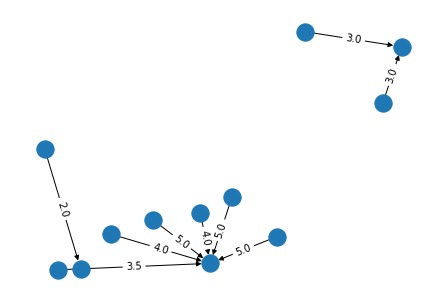

In [ ]:
# Read edge list
G = nx.read_weighted_edgelist(rates, create_using=nx.DiGraph)
# Extract weights
weights = [d['weight'] for s, t, d in G.edges(data=True)]
# Draw network
pos=nx.spring_layout(G, k=0.9)
nx.draw(G, pos, with_labels=False)

3. Una red donde se visualice la valoración. Puedes ver cuál película es la más vista y con mejores valoraciones

{('A1TADCM7YWPQ8M',
  '0000000868'): Text(0.003530163114723997, -0.6042579267333725, '2.0'),
 ('A2IIIDRK3PRRZY',
  '0000000116'): Text(-0.8592076398339172, -0.6931207213262673, '3.0'),
 ('A2SUAM1J3GNN3B',
  '0000013714'): Text(0.49873002438524283, 0.4269711696654635, '5.0'),
 ('A3BED5QFJWK88M',
  '0000013714'): Text(0.43005956586248334, 0.35824999724686146, '5.0'),
 ('A3UTQPQPM4TQO0',
  '0000013714'): Text(0.3927511092359558, 0.17200353745561453, '3.5'),
 ('A8ZS0I5L5V31B',
  '0000013714'): Text(0.396502818771061, 0.27466290266758686, '5.0'),
 ('ACNGUPJ3A3TM9',
  '0000013714'): Text(0.6099957095024516, 0.46056331566247133, '4.0'),
 ('AH2L9G3DQHHAJ',
  '0000000116'): Text(-0.7935415151747992, -0.5508215265708795, '3.0'),
 ('AWGH7V0BDOJKB',
  '0000013714'): Text(0.5697983410961642, 0.326944859095632, '4.0')}

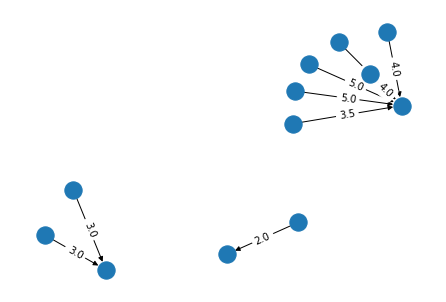

In [ ]:
pos=nx.spring_layout(G, k=0.9)
nx.draw(G, pos, with_labels=False)
edge_weight = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels = edge_weight)

# **TEMA 2. Analizando redes con NetworkX**

## 2.1 Club de karate

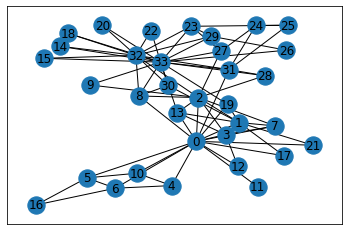

In [ ]:
G = nx.karate_club_graph()
karate_pos = nx.spring_layout(G, k=0.3)
nx.draw_networkx(G, karate_pos)

In [ ]:
list(G.nodes)

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33]

In [ ]:
list(G.edges)

[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 17),
 (0, 19),
 (0, 21),
 (0, 31),
 (1, 2),
 (1, 3),
 (1, 7),
 (1, 13),
 (1, 17),
 (1, 19),
 (1, 21),
 (1, 30),
 (2, 3),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 13),
 (2, 27),
 (2, 28),
 (2, 32),
 (3, 7),
 (3, 12),
 (3, 13),
 (4, 6),
 (4, 10),
 (5, 6),
 (5, 10),
 (5, 16),
 (6, 16),
 (8, 30),
 (8, 32),
 (8, 33),
 (9, 33),
 (13, 33),
 (14, 32),
 (14, 33),
 (15, 32),
 (15, 33),
 (18, 32),
 (18, 33),
 (19, 33),
 (20, 32),
 (20, 33),
 (22, 32),
 (22, 33),
 (23, 25),
 (23, 27),
 (23, 29),
 (23, 32),
 (23, 33),
 (24, 25),
 (24, 27),
 (24, 31),
 (25, 31),
 (26, 29),
 (26, 33),
 (27, 33),
 (28, 31),
 (28, 33),
 (29, 32),
 (29, 33),
 (30, 32),
 (30, 33),
 (31, 32),
 (31, 33),
 (32, 33)]

**Comprobando nodos**


In [ ]:
mr_hi = 0
mr_hi in G

True

In [ ]:
G.has_node(mr_hi)

True

**Cómo encontrar vecinos de un nodo**

In [ ]:
list(G.neighbors(mr_hi))

[1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]

Mr. Hi tiene 16 amigos, representados por su Id.

* ¿Cómo puedo saber si un Mr. Hi es amigo de una persona en especial?

In [ ]:
member_id = 1
(mr_hi, member_id) in G.edges

True

In [ ]:
G.has_edge(mr_hi, member_id)

True

In [ ]:
john_a = 33
(mr_hi, john_a) in G.edges

False

Veamos si Mr. Hi y John A son amigos 

In [ ]:
G.has_edge(mr_hi, john_a)

False

**Solución Activate 2**

1. Usa de la biblioteca Pandas para carga e inspecciona los datos del primer libro.

In [15]:
# Importing modules
import pandas as pd
# Reading in datasets/book1.csv
ruta= '/content/drive/MyDrive/Colab Notebooks/PROFUNDIZA_PARTICIPANTE/data/'
book1 = pd.read_csv(ruta+'book1.csv')

# Printing out the head of the dataset
book1.head()

,Source,Target,Type,weight,book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1
3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1


2. Crear el objeto Graph del primer libro

In [17]:
# Importing modules
import networkx as nx

# Creating an empty graph object
G_book1 = nx.Graph()

3. Presentar red



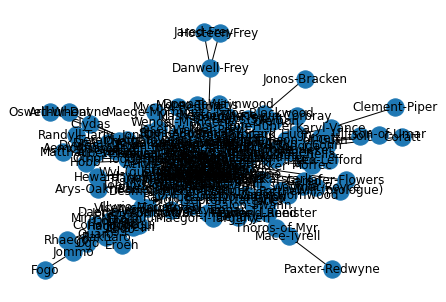

In [18]:
# Iterating through the DataFrame to add edges
for _, edge in book1.iterrows():
    G_book1.add_edge(edge['Source'], edge['Target'], weight=edge['weight'])
nx.draw(G_book1, with_labels=True)


4. Mejorando visualización

{'Addam-Marbrand': Text(-0.28574584327074676, -0.28147293939949025, 'Addam-Marbrand'),
 'Aegon-I-Targaryen': Text(0.4701572556209633, -0.02884108330567681, 'Aegon-I-Targaryen'),
 'Aemon-Targaryen-(Maester-Aemon)': Text(0.17920902595554233, -0.13330807391573984, 'Aemon-Targaryen-(Maester-Aemon)'),
 'Aerys-II-Targaryen': Text(0.06655228359657847, 0.15337275479134316, 'Aerys-II-Targaryen'),
 'Aggo': Text(0.7348541879413321, -0.2790021326194754, 'Aggo'),
 'Albett': Text(0.06115286494946343, -0.4035047982933603, 'Albett'),
 'Alliser-Thorne': Text(0.10725299467221643, -0.05918325994532741, 'Alliser-Thorne'),
 'Alyn': Text(-0.19429096847218477, 0.034160803379592236, 'Alyn'),
 'Arthur-Dayne': Text(-0.2736869328380741, 0.8571727747037879, 'Arthur-Dayne'),
 'Arya-Stark': Text(-0.04097453585267786, -0.044547775266113546, 'Arya-Stark'),
 'Arys-Oakheart': Text(-0.36579648756673927, -0.5483956453269754, 'Arys-Oakheart'),
 'Balon-Greyjoy': Text(0.3106517144558394, 0.17848357518313024, 'Balon-Greyjoy'

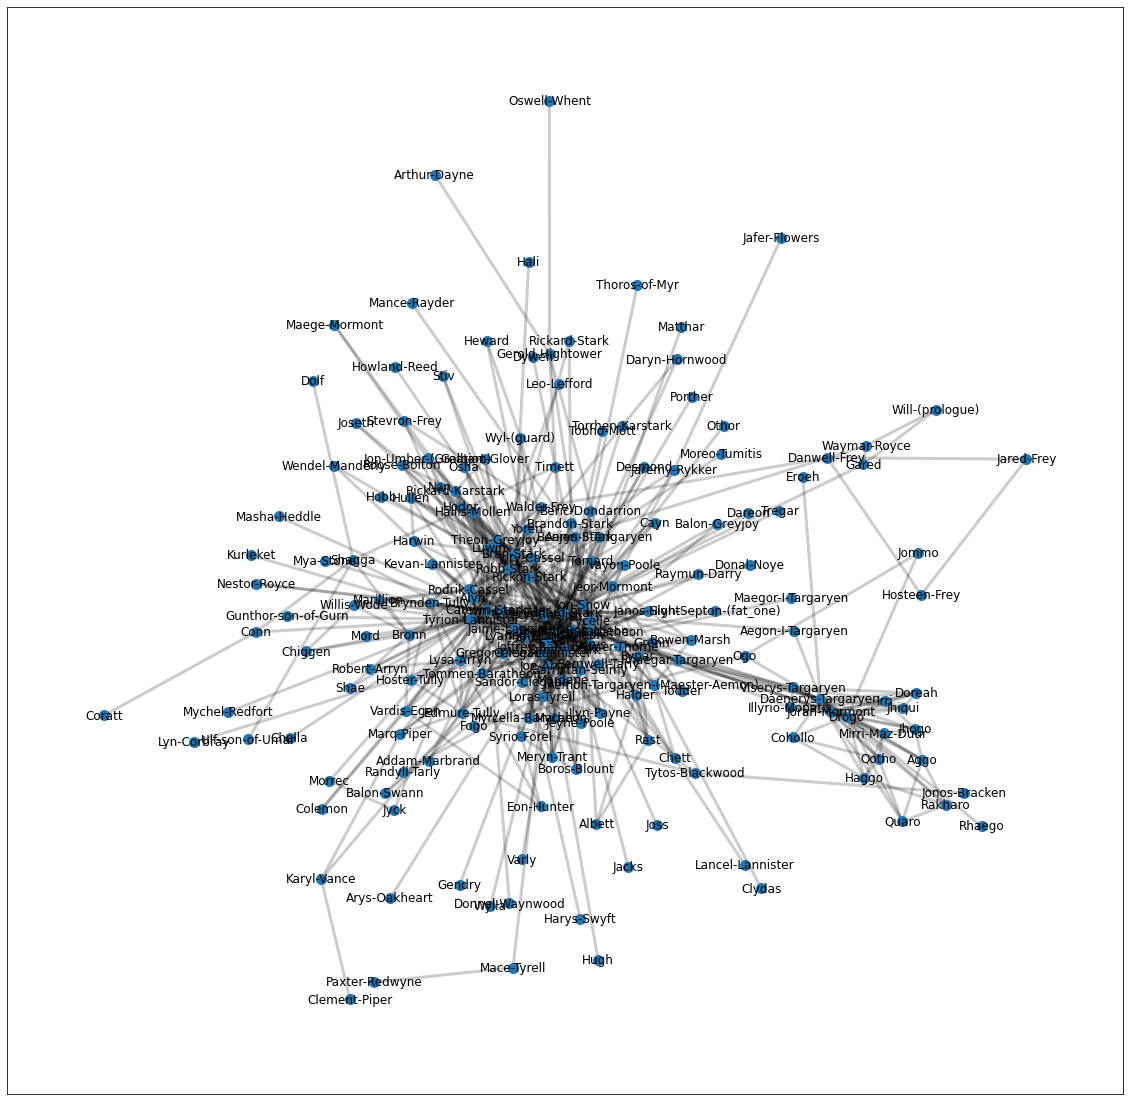

In [19]:
# Iterating through the DataFrame to add edges
for _, edge in book1.iterrows():
    G_book1.add_edge(edge['Source'], edge['Target'], weight=edge['weight'])

fig = plt.figure(figsize=(20, 20)) 
pos = nx.spring_layout(G_book1, k = 0.5)
nx.draw_networkx_edges(G_book1, pos, width=3, alpha=0.2)
nx.draw_networkx_nodes(G_book1, pos, node_size=100)
nx.draw_networkx_labels(G_book1, pos)

In [ ]:
JonSnow = 'Jon-Snow'
JonSnow in G_book1

True

In [ ]:
list(G_book1.neighbors(JonSnow))

['Aemon-Targaryen-(Maester-Aemon)',
 'Albett',
 'Alliser-Thorne',
 'Arya-Stark',
 'Benjen-Stark',
 'Bowen-Marsh',
 'Bran-Stark',
 'Catelyn-Stark',
 'Cersei-Lannister',
 'Chett',
 'Dareon',
 'Donal-Noye',
 'Dywen',
 'Eddard-Stark',
 'Grenn',
 'Halder',
 'Hobb',
 'Jaremy-Rykker',
 'Jeor-Mormont',
 'Joffrey-Baratheon',
 'Jory-Cassel',
 'Luwin',
 'Matthar',
 'Mordane',
 'Othor',
 'Pypar',
 'Rast',
 'Rickon-Stark',
 'Robb-Stark',
 'Robert-Baratheon',
 'Rodrik-Cassel',
 'Samwell-Tarly',
 'Sansa-Stark',
 'Theon-Greyjoy',
 'Todder',
 'Tyrion-Lannister',
 'Yoren']

# **TEMA 3. Manejo de atributos de un grafo**

**Añadiendo atributos**

In [ ]:
member_club = [
0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
1, 1, 1, 1]

In [ ]:
for node_id in G.nodes:
  G.nodes[node_id]["club"] = member_club[node_id]

In [ ]:
G.add_node(11, club=0)

In [ ]:
G.nodes[mr_hi]

{'club': 0}

In [ ]:
G.nodes[john_a]

{'club': 1}

In [ ]:
# Añadiendo color a los nodos
node_color = [
    '#1f78b4' if G.nodes[v]["club"] == 0
    else '#33a02c' for v in G]

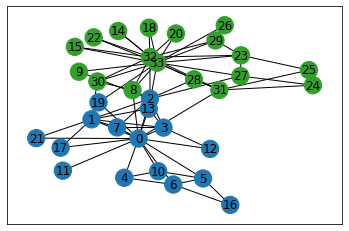

In [ ]:
nx.draw_networkx(G, karate_pos, label=True, node_color=node_color)

In [ ]:
for v, w in G.edges:
    # Compara la propiedad 'club' de cada nodo coenctado al arco
    # Coloca la propiedad 'interna' a Verdad si hay coincidencia
    if G.nodes[v]["club"] == G.nodes[w]["club"]:
        G.edges[v, w]["interna"] = True
    else:
        G.edges[v, w]["interna"] = False

In [ ]:
interna = [e for e in G.edges if G.edges[e]["interna"]]
externa = [e for e in G.edges if not G.edges[e]["interna"]]

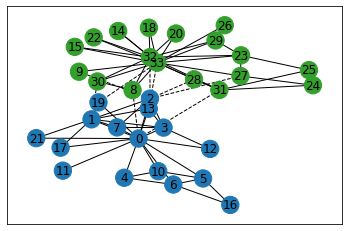

In [ ]:
# Graficar nodos y etiquetas
nx.draw_networkx_nodes(G, karate_pos, node_color=node_color)
nx.draw_networkx_labels(G, karate_pos)
# Graficar arcos internos con líneas solidas
nx.draw_networkx_edges(G, karate_pos, edgelist=interna)
# Graficar líneas externas con líneas punteadas
nx.draw_networkx_edges(G, karate_pos, edgelist=externa, style="dashed") 

## Añade pesos a las aristas
Los pesos en las aristas pueden representar diferentes cosas:
* Cuantificar la fuerza de la relación, por ejemplo, cada cuando dos amigos hablan.
* El volumen de flujo que una tuberia puede transportar.
* La distancia entre dos ciudades.
* El tie strength

El **tie strength** describe el lazo entre dos nodos. Esta propiedad se incremente con el número de vecinos entre dos nodos. 

In [ ]:
def tie_strength(G, v, w):
    # obtener vecinos de los nodos v, w
    v_neighbors = set(G.neighbors(v))
    w_neighbors = set(G.neighbors(w))
    # Regresa el tamaño dela intersección
    return 1 + len(v_neighbors & w_neighbors)

In [ ]:
# Dibujar la red con el grosor del arco relacionado con el peso
for v, w in G.edges: 
    G.edges[v, w]["weight"] = tie_strength(G, v, w)
# se almacenan los pesos en una lista
edge_weights = [G.edges[v, w]["weight"] for v, w in G.edges] 

In [ ]:
weighted_pos = nx.spring_layout(G, pos=karate_pos, k=0.3, weight="weight")

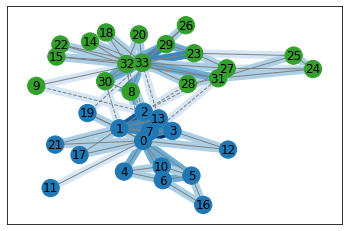

In [ ]:
# Dibujar la red con el grosor del arco relacionado con el peso
nx.draw_networkx(
    G, weighted_pos, width=8, node_color=node_color,
    edge_color=edge_weights, edge_vmin=0, edge_vmax=6, edge_cmap=plt.cm.Blues)
# Dibujar líneas continuas / discontinuas en la parte superior de los bordes internos / externos
nx.draw_networkx_edges(G, weighted_pos, edgelist=interna, edge_color="gray")
nx.draw_networkx_edges(G, weighted_pos, edgelist=externa, edge_color="gray", style="dashed")

In [ ]:
# Calculating the degree centrality of karate club
deg_cen_karate = nx.degree_centrality(G)

# Sorting the dictionaries according to their  degree centrality and extracting the top 10
sorted_deg_cen_karate = sorted(deg_cen_karate.items(), key=lambda x:x[1], reverse=True)[0:10]

# Printing out the top 10
print("karate club", sorted_deg_cen_karate)


Club Karate [(33, 0.5151515151515151), (0, 0.48484848484848486), (32, 0.36363636363636365), (2, 0.30303030303030304), (1, 0.2727272727272727), (3, 0.18181818181818182), (31, 0.18181818181818182), (8, 0.15151515151515152), (13, 0.15151515151515152), (23, 0.15151515151515152)]


In [ ]:
# Calculating the betweenness centrality of karate club
bet_cen_karate = nx.betweenness_centrality(G)

# Sorting the dictionaries according to their  betweenness centrality and extracting the top 10
sorted_bet_cen_karate = sorted(bet_cen_karate.items(), key=lambda x:x[1], reverse=True)[0:10]

# Printing out the top 10
print("karate club", sorted_bet_cen_karate)


karate club [(0, 0.43763528138528146), (33, 0.30407497594997596), (32, 0.145247113997114), (2, 0.14365680615680618), (31, 0.13827561327561325), (8, 0.05592682780182781), (1, 0.053936688311688304), (13, 0.04586339586339586), (19, 0.03247504810004811), (5, 0.02998737373737374)]


**Activate Tema 3**

1. Encuntra los 10 personajes más importantes del libro 1 de acuerdo a la centralidad de grado

In [20]:
# Calculating the degree centrality of Book 1
deg_cen_G_book1 = nx.degree_centrality(G_book1)

# Sorting the dictionaries according to their  degree centrality and extracting the top 10
sorted_deg_cen_G_book1 = sorted(deg_cen_G_book1.items(), key=lambda x:x[1], reverse=True)[0:10]

# Printing out the top 10
print("book1", sorted_deg_cen_G_book1)


book1 [('Eddard-Stark', 0.3548387096774194), ('Robert-Baratheon', 0.2688172043010753), ('Tyrion-Lannister', 0.24731182795698928), ('Catelyn-Stark', 0.23118279569892475), ('Jon-Snow', 0.19892473118279572), ('Robb-Stark', 0.18817204301075272), ('Sansa-Stark', 0.18817204301075272), ('Bran-Stark', 0.17204301075268819), ('Cersei-Lannister', 0.16129032258064518), ('Joffrey-Baratheon', 0.16129032258064518)]


1. Encuntra los 10 personajes más importantes del libro 1 de acuerdo a la centralidad de intermediación

In [21]:
# Calculating the betweenness centrality of book 1
bet_cen_G_book1 = nx.betweenness_centrality(G_book1)

# Sorting the dictionaries according to their  betweenness centrality and extracting the top 10
sorted_bet_cen_G_book1 = sorted(bet_cen_G_book1.items(), key=lambda x:x[1], reverse=True)[0:10]

# Printing out the top 10
print("book 1", sorted_bet_cen_G_book1)

book 1 [('Eddard-Stark', 0.2696038913836117), ('Robert-Baratheon', 0.21403028397371796), ('Tyrion-Lannister', 0.1902124972697492), ('Jon-Snow', 0.17158135899829566), ('Catelyn-Stark', 0.1513952715347627), ('Daenerys-Targaryen', 0.08627015537511595), ('Robb-Stark', 0.07298399629664767), ('Drogo', 0.06481224290874964), ('Bran-Stark', 0.05579958811784442), ('Sansa-Stark', 0.03714483664326785)]


#**Tema 4 Redes bipartitas o de afiliación**

###**Subtema 1 Redes de afiliación**

In [22]:
from networkx.algorithms import bipartite
B = nx.Graph() #No separate class for bipartite graphs
B.add_nodes_from(['Señor de los anillos','El Hobbit','Piratas del caribe','Sin city'], bipartite=0) #label one set of nodes 0
B.add_nodes_from(['Elijah Wood', 'Orlando Bloom', 'Keira Knightley', 'Jessica Alba'], bipartite=1) #label other set of nodes 1
B.add_edges_from([('Señor de los anillos','Elijah Wood'), ('Señor de los anillos','Orlando Bloom'), ('El Hobbit','Elijah Wood'), ('El Hobbit','Orlando Bloom'), ('Piratas del caribe','Orlando Bloom'), ('Piratas del caribe','Keira Knightley'), ('Sin city','Elijah Wood'),('Sin city','Jessica Alba')])

**Verificar si un grafo es bipartito**

In [23]:
bipartite.is_bipartite(B)

True

Añadamos un arco entre el mismo grupo de nodos y revisemos si sigue siendo bipartito

In [ ]:
B.add_edge('Elijah Wood', 'Orlando Bloom')
bipartite.is_bipartite(B)

removemos el arco anterior

In [ ]:
B.remove_edge('Elijah Wood', 'Orlando Bloom')

**Verificar si un conjunto de nodos es una bipartición del grafo**

In [24]:
X = set(['Señor de los anillos','El Hobbit','Piratas del caribe','Sin city'])
bipartite.is_bipartite_node_set(B,X)

True

**Obtener cada conjunto de nodos en un grafo bipartito**

In [25]:
bipartite.is_bipartite_node_set(B,X)

True

**Subtema 2 Modelado de sistemas con relaciones complejas**

In [26]:
B = nx.Graph()
B.add_edges_from([('A',1), ('B',1),
('C',1),('D',1),('H',1), ('B', 2), ('C', 2), ('D',
2),('E', 2), ('G', 2), ('E', 3), ('F', 3), ('H', 3),
('J', 3), ('E', 4), ('I', 4), ('J', 4) ])

In [27]:
fans = set(['A','B','C','D', 'E', 'F','G', 'H', 'I','J'])
fans_dict = {node: (node in fans) for node in B}
nx.set_node_attributes(B, fans_dict, "Fan")

In [28]:
# Get node set of teams
teams = [v for v in B.nodes if B.nodes[v]["Fan"] == False]

{1: Text(-0.17087824880882385, -0.20508393500224634, '1'),
 2: Text(-0.396876413854089, -0.3821591029327933, '2'),
 3: Text(0.6987107363456252, 0.4015376572760664, '3'),
 4: Text(0.312685500714789, 0.26076521837424504, '4'),
 'A': Text(-0.2103553449074615, -0.9617215699218448, 'A'),
 'B': Text(0.2895443066931645, -0.3853686260586672, 'B'),
 'C': Text(-0.8017162763436438, -0.24358985276167364, 'C'),
 'D': Text(-0.31349867659795194, 0.25392574082701713, 'D'),
 'E': Text(0.21216034819595123, -0.1666769700797088, 'E'),
 'F': Text(0.40601902832249037, 1.0, 'F'),
 'G': Text(-0.9735923700977737, -0.766480986343485, 'G'),
 'H': Text(0.3178954813107403, 0.46232236498309454, 'H'),
 'I': Text(-0.23930071476387002, 0.8239402039300514, 'I'),
 'J': Text(0.8692026437908532, -0.09141014229005545, 'J')}

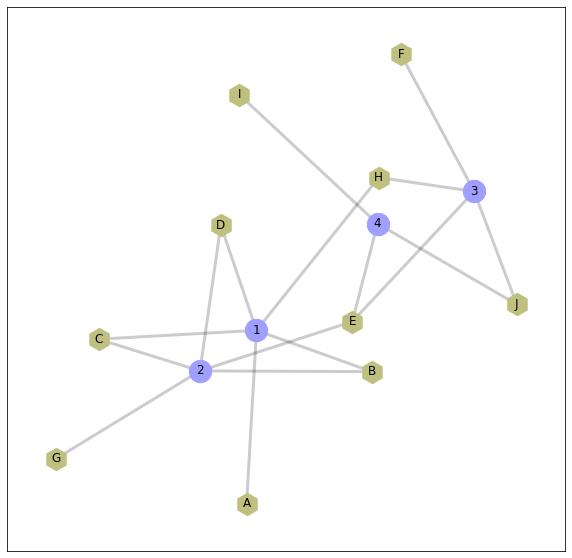

In [29]:
pos = nx.spring_layout(B, k = 0.9)
# Draw using different shapes and colors for plant/pollinators
fig = plt.figure(figsize=(10, 10)) 
nx.draw_networkx_edges(B, pos, width=3, alpha=0.2)
nx.draw_networkx_nodes(B, pos, nodelist=fans, node_color="#bfbf7f",
node_shape="h", node_size=500)
nx.draw_networkx_nodes(B, pos, nodelist=teams, node_color="#9f9fff", node_size=500)
nx.draw_networkx_labels(B, pos)

{'A': Text(-0.8496950303463807, 0.029362132697721855, 'A'),
 'B': Text(-0.2072955347163107, 0.3372175520506992, 'B'),
 'C': Text(-0.4413575786714584, 0.1156769558221819, 'C'),
 'D': Text(-0.5030256474799321, 0.4409140250325297, 'D'),
 'E': Text(0.22683336700812323, 0.03380887179106078, 'E'),
 'F': Text(0.5762170399620101, -0.2909025429965167, 'F'),
 'G': Text(-0.07174335085277604, 0.7342353974733661, 'G'),
 'H': Text(-0.15685988163680809, -0.22235412855281012, 'H'),
 'I': Text(1.0, -0.5126929612617992, 'I'),
 'J': Text(0.4269266167335322, -0.6652653020564337, 'J')}

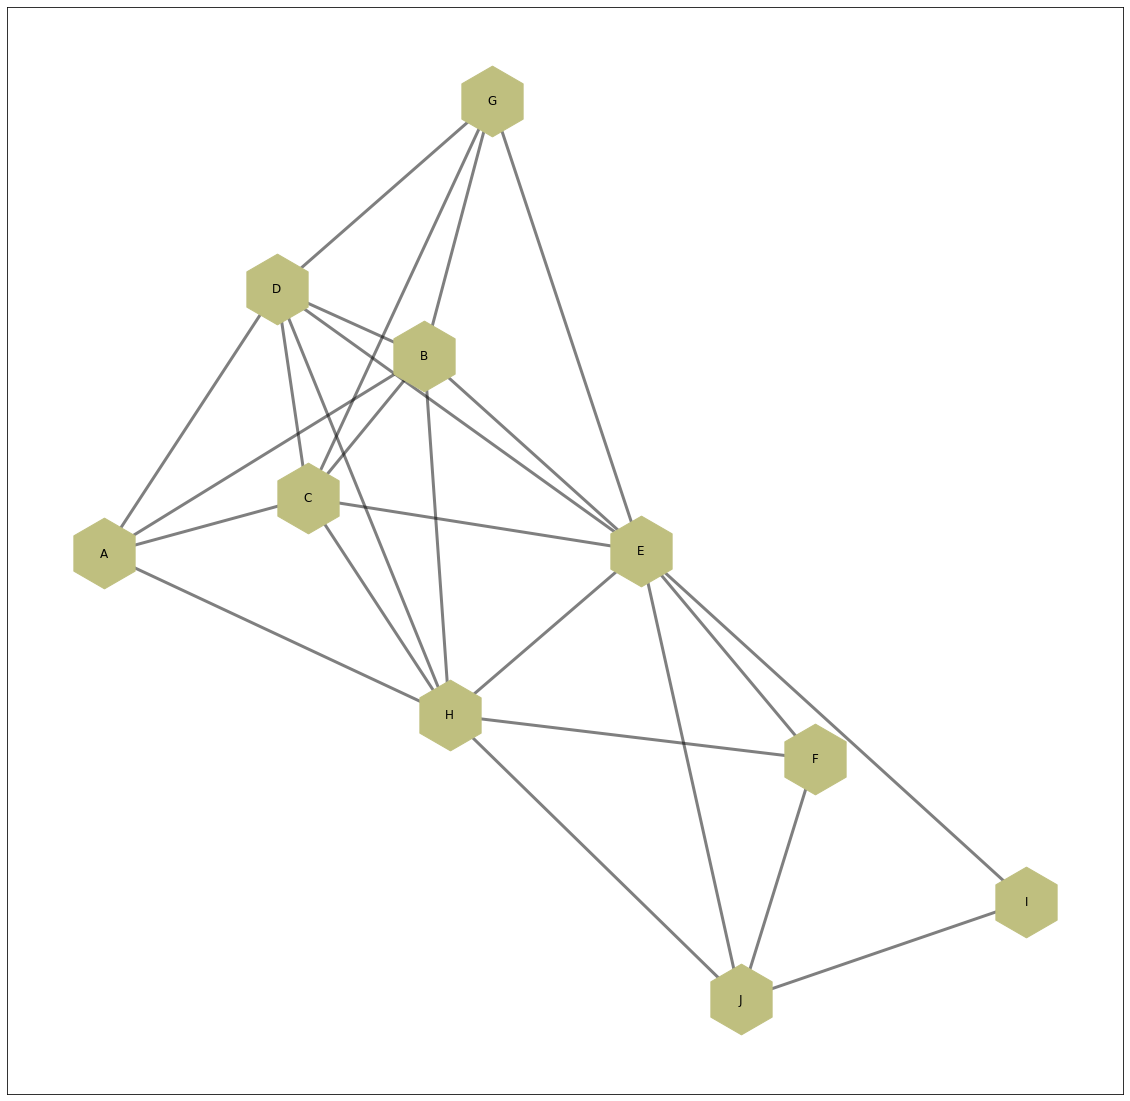

In [30]:
# Create co-affiliation network
P = bipartite.projected_graph(B, fans)
# Create figure
plt.figure(figsize=(20,20))
# Calculate layout
pos = nx.spring_layout(P, k=0.5)
# Draw edges, nodes, and labels
nx.draw_networkx_edges(P, pos, width=3, alpha=0.5)
nx.draw_networkx_nodes(P, pos, node_color="#bfbf7f", node_shape="h", node_size=5000)
nx.draw_networkx_labels(P, pos)

{1: Text(-0.9998240525299688, -0.08164195955481351, '1'),
 2: Text(0.037912814615113, -0.46538095778509314, '2'),
 3: Text(-0.0380887620851441, 0.4653665761736633, '3'),
 4: Text(1.0, 0.08165634116624325, '4')}

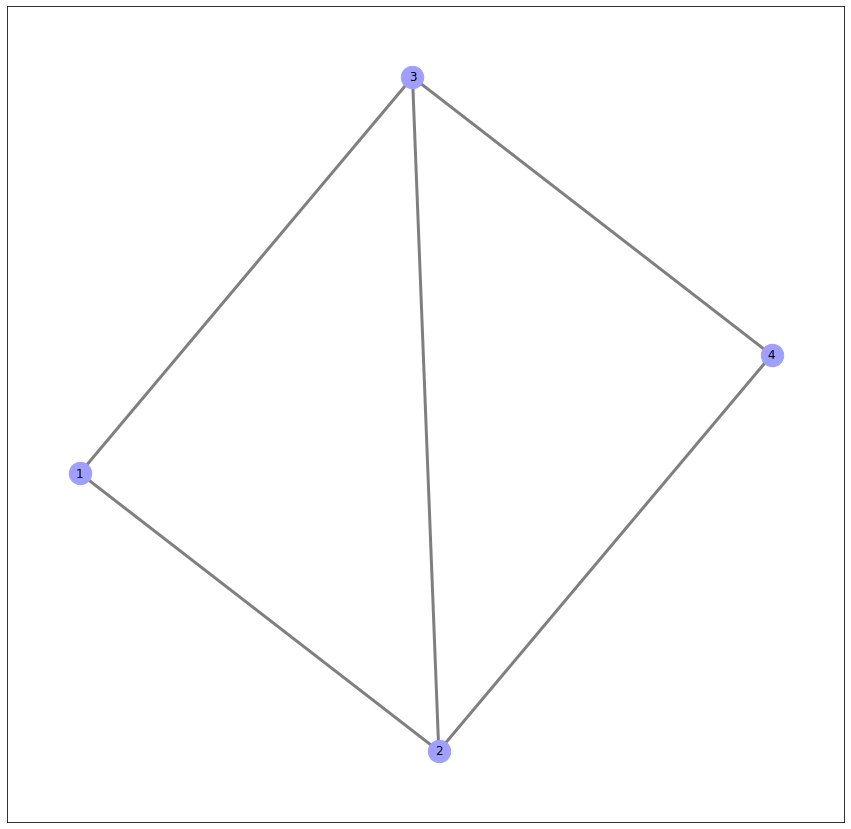

In [31]:
# Create co-affiliation network
P = bipartite.projected_graph(B, teams)
# Create figure
plt.figure(figsize=(15,15))
# Calculate layout
pos = nx.spring_layout(P, k=0.5)
# Draw edges, nodes, and labels
nx.draw_networkx_edges(P, pos, width=3, alpha=0.5)
nx.draw_networkx_nodes(P, pos, nodelist=teams, node_color="#9f9fff", node_size=500)
nx.draw_networkx_labels(P, pos)

##**Activate Tema 4**

**1.	Crear el grafo a partir del archivo csv**

In [34]:
import csv
path_nutrientes = '/content/drive/MyDrive/Colab Notebooks/PROFUNDIZA_PARTICIPANTE/data/nutrientes_completo.csv'

with open(path_nutrientes) as infile:
  csv_reader = csv.reader(infile)
  nutrientes_red = nx.Graph(csv_reader)
print(nutrientes_red.nodes())

['A', 'carrots', 'eggs', 'fatty fish', 'green leafy vegs', 'liver', 'milk', 'tomatoes', 'B12', 'beef', 'poultry', 'B6', 'asparagus', 'beans', 'kidneys', 'potatoes', 'C', 'pumpkins', 'broccoli', 'Ca', 'cheese', 'yogurt', 'Cu', 'nuts', 'whole grains', 'shellfish', 'D', 'mushrooms', 'E', 'seeds', 'veg oils', 'folates', 'Mn', 'legumes', 'wheat', 'niacin', 'riboflavin', 'Se', 'thiamin', 'Zn', 'spinach']


**2.	Identificar los nodos y agregar el atributo 'nutriente'**

In [35]:
nutrientes = set(('A', 'B12', 'B6', 'C', 'Ca', 'Cu', 'D', 'E', 'folates', 'Mn', 'niacin', 'riboflavin', 'Se', 'thiamin', 'Zn'))

nutrientes_dict = {node: (node in nutrientes) for node in nutrientes_red}
nutrientes_dict

nx.set_node_attributes(nutrientes_red, nutrientes_dict, "nutriente")

# Get node set of teams
alimentos = [v for v in nutrientes_red.nodes if nutrientes_red.nodes[v]["nutriente"] == False]

**3.	Crear y visualizar la red bipartita**

{'A': Text(0.3011547130687448, -0.15151263921642547, 'A'),
 'B12': Text(0.059595480172529414, 0.34865236477583283, 'B12'),
 'B6': Text(0.13006005252303932, 0.11344274197597498, 'B6'),
 'C': Text(0.8450458292692111, 0.21159773996977013, 'C'),
 'Ca': Text(0.05956586420059929, 0.06838050762449058, 'Ca'),
 'Cu': Text(-0.13853211569068175, -0.2169339931546534, 'Cu'),
 'D': Text(0.8527913664593946, -0.24574203944617667, 'D'),
 'E': Text(0.08571793176559886, -0.11352713311700682, 'E'),
 'Mn': Text(-0.3561769698238307, -0.02934339768133585, 'Mn'),
 'Se': Text(-0.39938344451926916, -0.9107149966505852, 'Se'),
 'Zn': Text(-0.1444575386259345, 0.07290339595761984, 'Zn'),
 'asparagus': Text(0.5065115839368025, -0.22206789284568665, 'asparagus'),
 'beans': Text(0.34473190454599506, 0.411935389538373, 'beans'),
 'beef': Text(-0.1948475457779624, 0.3218629796650218, 'beef'),
 'broccoli': Text(0.48243927254246205, 0.6160183259047327, 'broccoli'),
 'carrots': Text(0.6782285659198497, -0.605701955570324

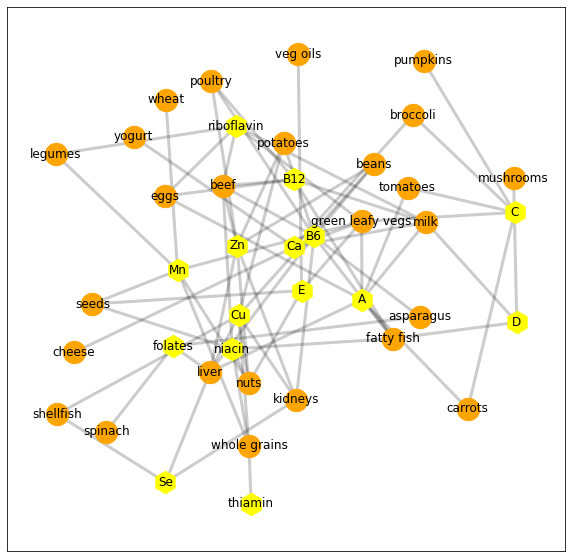

In [36]:
pos = nx.spring_layout(nutrientes_red, k = 0.9)
# Draw using different shapes and colors for plant/pollinators
fig = plt.figure(figsize=(10, 10)) 
nx.draw_networkx_edges(nutrientes_red, pos, width=3, alpha=0.2)
nx.draw_networkx_nodes(nutrientes_red, pos, nodelist=nutrientes, node_color="#FFFF00", node_shape="h", node_size=500)
nx.draw_networkx_nodes(nutrientes_red, pos, nodelist=alimentos, node_color="#FFA500", node_size=500)
nx.draw_networkx_labels(nutrientes_red, pos)

**4.	Realizar las proyecciones de ambos tipos de nodo**

{'A': Text(0.11227313363617064, -0.11476108169505116, 'A'),
 'B12': Text(0.5568117516625599, -0.440251343078737, 'B12'),
 'B6': Text(0.037959555172070454, -0.6279594263639252, 'B6'),
 'C': Text(0.5142403799163873, 0.906460952198254, 'C'),
 'Ca': Text(0.7771621615625561, 0.4130049682427861, 'Ca'),
 'Cu': Text(-0.635255803485324, -0.05184980825045353, 'Cu'),
 'D': Text(0.864317392551342, -0.2404131819762088, 'D'),
 'E': Text(0.1182533749159348, 0.5406915232975353, 'E'),
 'Mn': Text(-0.20086719627857308, 0.5894029743943898, 'Mn'),
 'Se': Text(-0.7710519563267406, -0.703902179416355, 'Se'),
 'Zn': Text(-0.24587488916105163, -0.27886120388539704, 'Zn'),
 'folates': Text(-0.45486344406709006, -0.9585061722098335, 'folates'),
 'niacin': Text(-0.11454400048571202, 0.12551529872262973, 'niacin'),
 'riboflavin': Text(0.44143954038746974, 0.14701145329557883, 'riboflavin'),
 'thiamin': Text(-0.9999999999999999, 0.694417226724788, 'thiamin')}

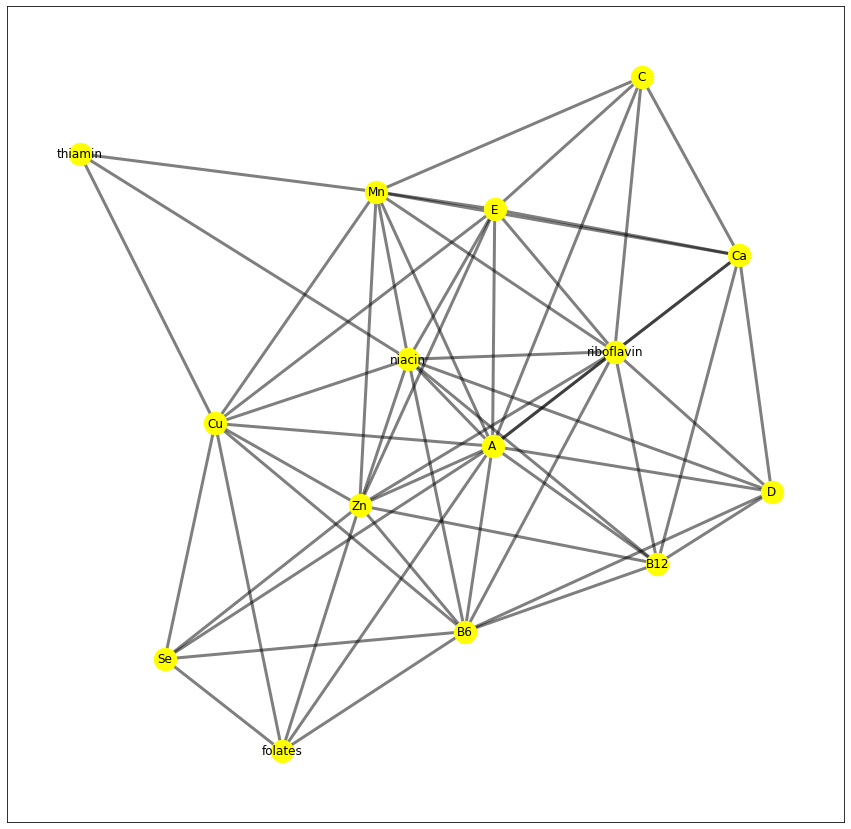

In [37]:
# Create co-affiliation network
nutrientes_proyeccion = bipartite.projected_graph(nutrientes_red, nutrientes)
# Create figure
plt.figure(figsize=(15,15))
# Calculate layout
pos = nx.spring_layout(nutrientes_proyeccion, k=0.5)
# Draw edges, nodes, and labels
nx.draw_networkx_edges(nutrientes_proyeccion, pos, width=3, alpha=0.5)
nx.draw_networkx_nodes(nutrientes_proyeccion, pos, nodelist=nutrientes, node_color="#FFFF00", node_size=500)
nx.draw_networkx_labels(nutrientes_proyeccion, pos)

{'asparagus': Text(-0.2514100514083322, -0.698447610700654, 'asparagus'),
 'beans': Text(0.02512371974869621, -0.5838074475549088, 'beans'),
 'beef': Text(0.09027044345855685, -0.1980951458083114, 'beef'),
 'broccoli': Text(-0.26200186683589965, 0.7927099371125348, 'broccoli'),
 'carrots': Text(-0.4675327438547389, 0.3114102030112453, 'carrots'),
 'cheese': Text(-0.06944719098844977, 1.0, 'cheese'),
 'eggs': Text(-0.23344746473178266, 0.0788151898692378, 'eggs'),
 'fatty fish': Text(-0.10580687400774594, -0.11542380709014115, 'fatty fish'),
 'green leafy vegs': Text(0.10232859678995823, 0.33518515751190836, 'green leafy vegs'),
 'kidneys': Text(0.2112243904035187, -0.5466024741094705, 'kidneys'),
 'legumes': Text(0.3164040425374199, 0.17711583688996121, 'legumes'),
 'liver': Text(-0.15281623142134385, -0.26998935109144817, 'liver'),
 'milk': Text(-0.16250637011625405, 0.31348542738468255, 'milk'),
 'mushrooms': Text(-0.8134638315722778, 0.08335351048401915, 'mushrooms'),
 'nuts': Text(

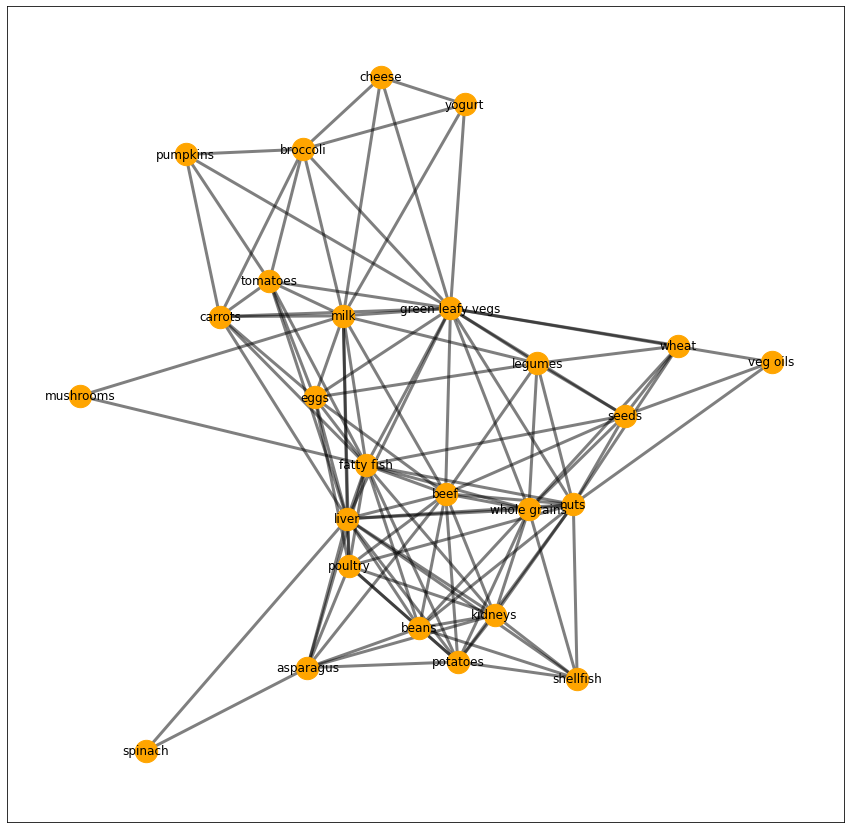

In [38]:
# Create co-affiliation network
nutrientes_proyeccion = bipartite.projected_graph(nutrientes_red, alimentos)
# Create figure
plt.figure(figsize=(15,15))
# Calculate layout
pos = nx.spring_layout(nutrientes_proyeccion, k=0.5)
# Draw edges, nodes, and labels
nx.draw_networkx_edges(nutrientes_proyeccion, pos, width=3, alpha=0.5)
nx.draw_networkx_nodes(nutrientes_proyeccion, pos, nodelist=alimentos, node_color="#FFA500", node_size=500)
nx.draw_networkx_labels(nutrientes_proyeccion, pos)